In [28]:
import pandas as pd
import numpy as np

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.shape)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [36]:
print(df.isnull().sum())


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [37]:
print(df.duplicated().sum())

0


In [38]:
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

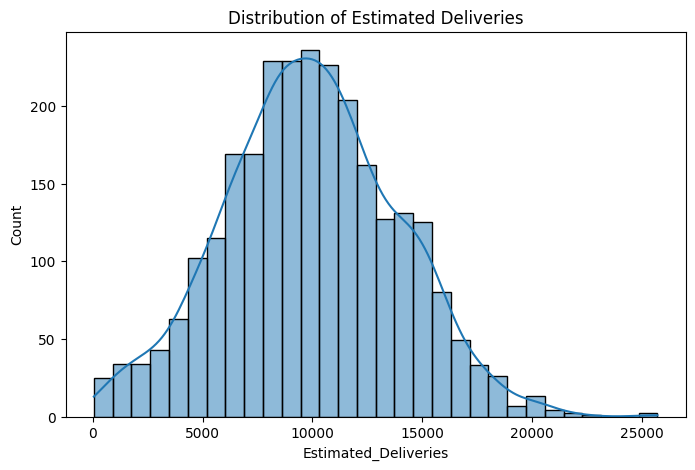

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

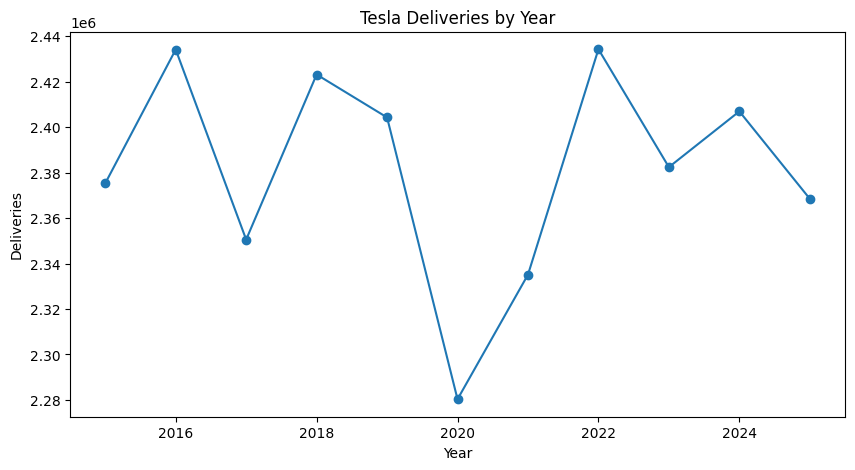

In [40]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title("Tesla Deliveries by Year")
plt.ylabel("Deliveries")
plt.show()

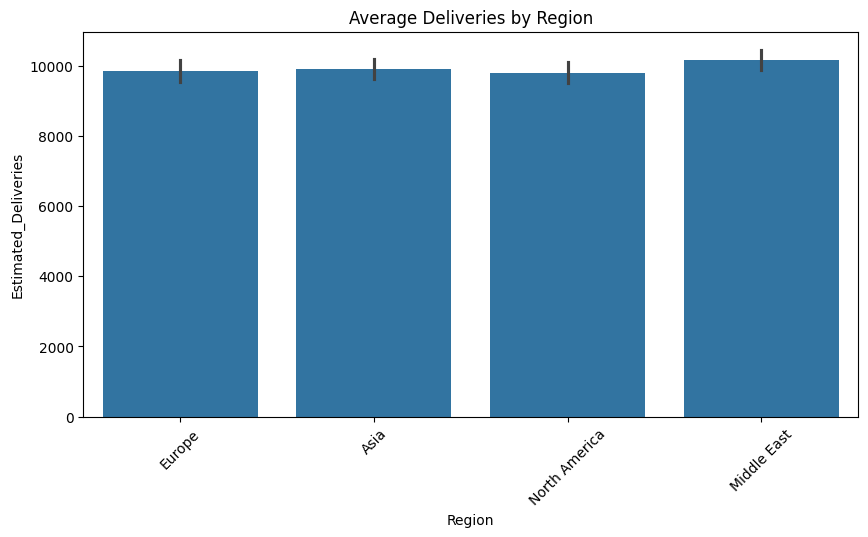

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    estimator=np.mean
)

plt.xticks(rotation=45)
plt.title("Average Deliveries by Region")
plt.show()

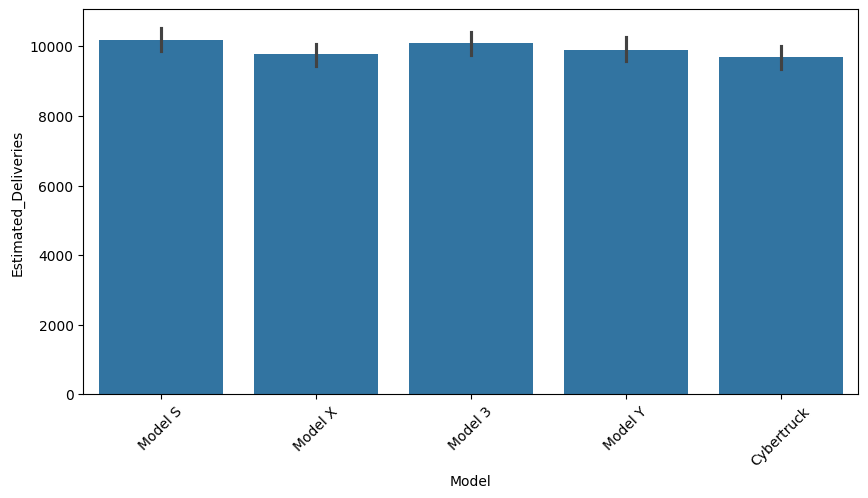

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries',
    estimator=np.mean
)

plt.xticks(rotation=45)
plt.show()

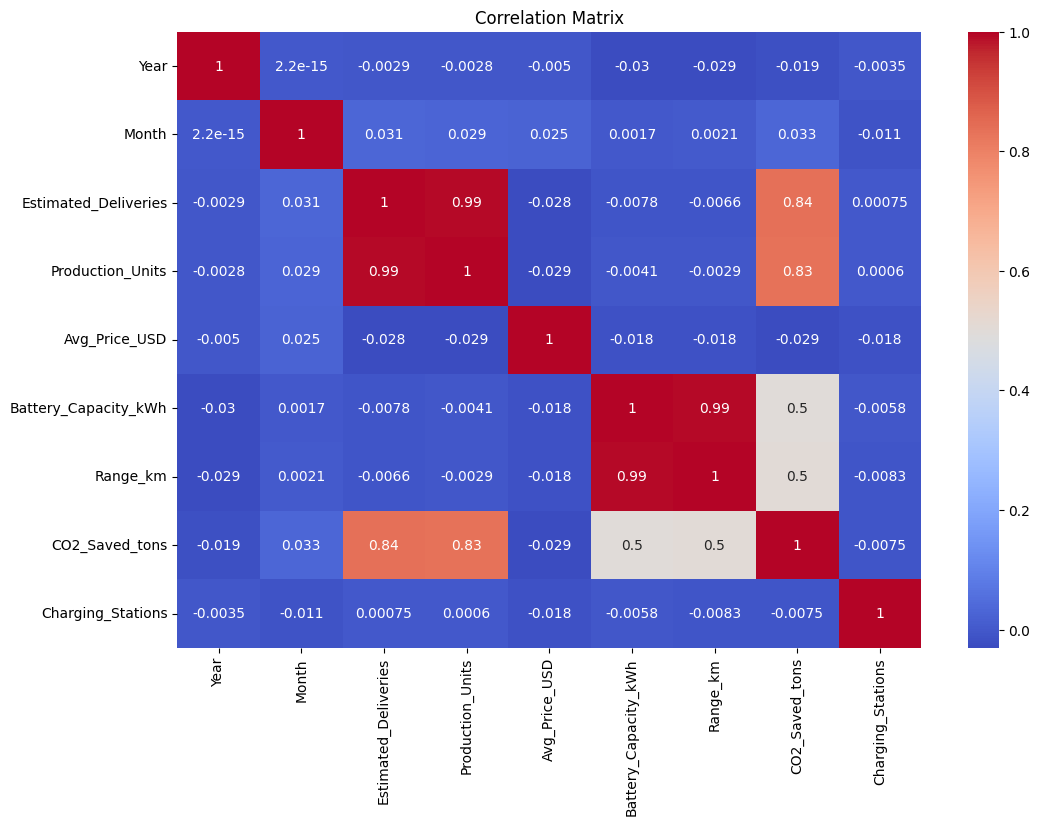

In [43]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [44]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [45]:
X = df.drop(
    ['Estimated_Deliveries','Date'],
    axis=1
)

y = df['Estimated_Deliveries']

In [46]:
num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

print(num_cols)
print(cat_cols)

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')
Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [47]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            StandardScaler(),
            num_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
model = Pipeline([

    ('preprocessor', preprocessor),

    ('regressor',
     RandomForestRegressor(
         random_state=42
     ))
])

In [50]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [51]:
y_pred = model.predict(X_test)

In [52]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 322.9511363636364
RMSE: 408.08339627430655
R2  : 0.9888280665971502


In [53]:
param_grid = {

    'regressor__n_estimators':[100,200],

    'regressor__max_depth':[10,20,None],

    'regressor__min_samples_split':[2,5],

    'regressor__min_samples_leaf':[1,2]
}

In [54]:
grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1,

    verbose=1
)

grid.fit(X_train,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [10, 20, None],
                         'regressor__min_samples_leaf': [1, 2],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [55]:
print(grid.best_params_)
print(grid.best_score_)

{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
0.9880424351450037


In [56]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(
    "R2 Score:",
    r2_score(y_test,y_pred)
)

R2 Score: 0.9887619852840809


In [57]:
rf = best_model.named_steps['regressor']

feature_names = (

    best_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importance = rf.feature_importances_

feature_imp = pd.DataFrame({

    'Feature':feature_names,

    'Importance':importance

}).sort_values(
    by='Importance',
    ascending=False
)

print(feature_imp.head(20))

                                  Feature  Importance
2                   num__Production_Units    0.990710
6                     num__CO2_Saved_tons    0.002278
5                           num__Range_km    0.001325
3                      num__Avg_Price_USD    0.001283
7                  num__Charging_Stations    0.001141
0                               num__Year    0.000814
1                              num__Month    0.000736
4               num__Battery_Capacity_kWh    0.000153
17    cat__Source_Type_Estimated (Region)    0.000150
13                     cat__Model_Model 3    0.000148
19    cat__Source_Type_Official (Quarter)    0.000140
11              cat__Region_North America    0.000140
16                     cat__Model_Model Y    0.000140
10                cat__Region_Middle East    0.000138
8                        cat__Region_Asia    0.000134
18  cat__Source_Type_Interpolated (Month)    0.000131
9                      cat__Region_Europe    0.000120
14                     cat__

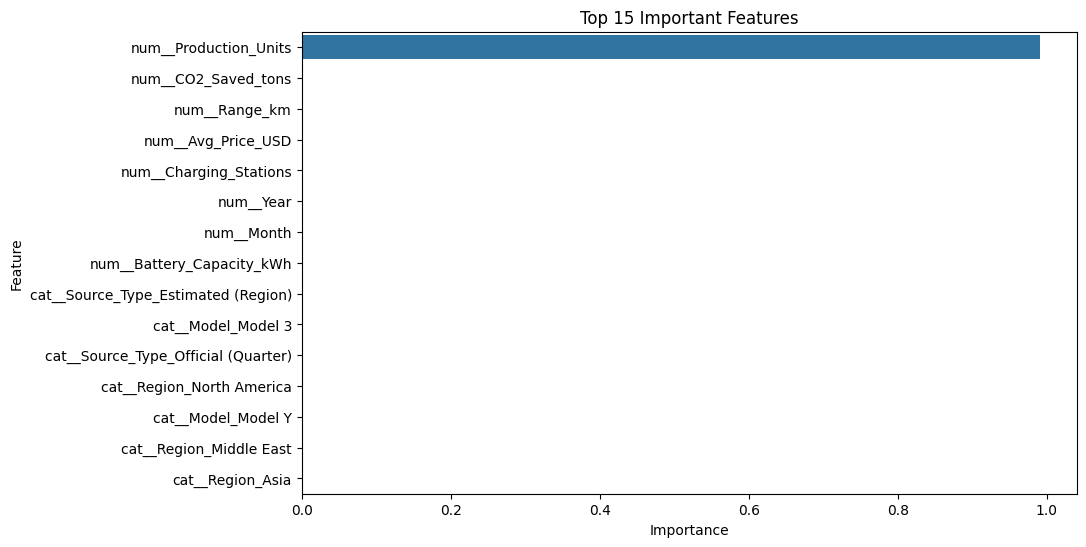

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_imp.head(15),

    x='Importance',

    y='Feature'
)

plt.title("Top 15 Important Features")

plt.show()

In [59]:
ts = df.groupby('Date')[
    'Estimated_Deliveries'
].sum()

ts = ts.sort_index()

print(ts.head())

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


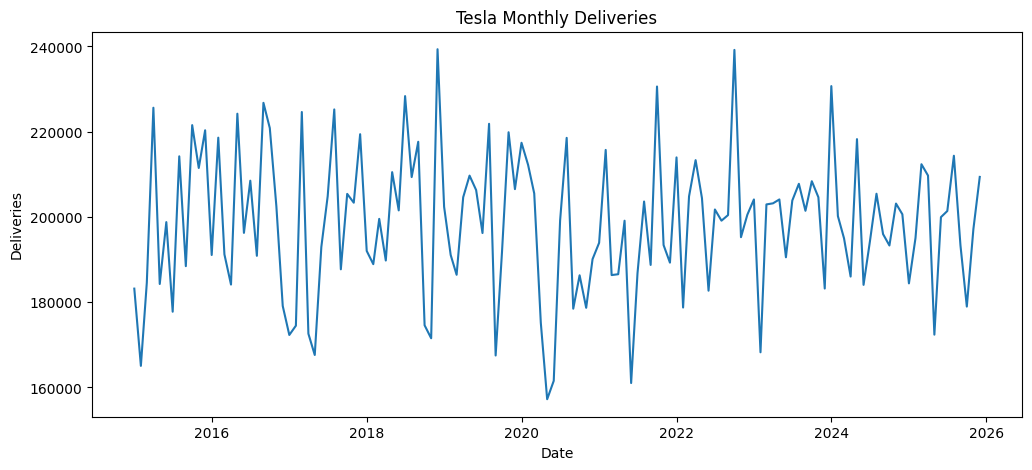

In [60]:
plt.figure(figsize=(12,5))

plt.plot(
    ts.index,
    ts.values
)

plt.title("Tesla Monthly Deliveries")

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(
    ts,
    order=(5,1,0)
)

model_fit = model_arima.fit()

print(model_fit.summary())

In [ ]:
forecast = model_fit.forecast(
    steps=12
)

print(forecast)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label='Actual'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast'
)

plt.legend()

plt.title(
    "Next 12 Months Forecast"
)

plt.show()plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label='Actual'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast'
)

plt.legend()

plt.title(
    "Next 12 Months Forecast"
)

plt.show()